<a href="https://colab.research.google.com/github/NeoExchangedCorgi/mvp_yt_shorts_machine_learning/blob/main/YT_Shorts_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Gusthavo Silva de Oliveira

**Matrícula:** 4052026000142

**Data:** 06/2026  

**Dataset:** [Youtube Shorts Dataset  ](https://www.kaggle.com/datasets/prince7489/youtube-shorts-performance-dataset?resource=download)

**Tipo de problema:** Regressão

# ***Nota Importante Minha***

Este MVP foi construído com o auxílio de IA *(do próprio Colab inclusive)* com três objetivos: verificar **erros** de sintaxe; simplificar a **codificação**; facilitar a **estilização** do Notebook.

# 1. Definição do Problema

## 1.1 Descrição do problema

Todo criador de conteúdo, seja um iniciante curioso ou profissional antenado, que produz YouTube Shorts se tortura com a mesma pergunta antes de publicar um vídeo:

_“Se eu postar este vídeo, vai ser bem visualizado?”_

Desde sempre, os criadores dependem de intuição, testes, sorte e maneirismos de outros criadores de conteúdo (em tese, _concorrentes_) para estimar o desempenho dos próprios vídeos.

Fatores como duração do short, quantidade de hashtags, horário da postagem e categoria do conteúdo (Comedy, Tech, Food, etc.) influenciam bastante o resultado, mas não existe uma forma prática e objetiva de prever o potencial de views antes da publicação.

Este trabalho busca ajudar a contornar esse obstáculo real: prever o número de visualizações de um YouTube Short com base nas características conhecidas do vídeo no momento da postagem.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning capazes de prever a quantidade de visualizações de um vídeo Shorts no YouTube, utilizando características como duração, quantidade de hashtags, horário de upload e categoria (atributos do dataset escolhido).

Há de se comparar um modelo simples (baseline) com modelos mais elaborados, entender quais fatores mais influenciam o desempenho e entregar uma solução que possa ajudar criadores de conteúdo a terem uma estimativa mais realista antes de publicar.

## 1.3 Tipo de problema

**Tipo escolhido:** Regressão

**Justificativa:** Estamos tentando prever um valor numérico contínuo (o número de _views_), e não uma categoria ou grupo. Problemas de regressão são ideais quando queremos estimar quantidades, como vendas, preços, temperaturas ou, neste caso, visualizações.

## 1.4 Premissas, hipóteses e critérios de sucesso

### Hipóteses iniciais:

1. Primeira:

As características do vídeo (duração, hashtags, horário e categoria) têm influência significativa no número de visualizações.

2. Segunda:

É possível obter uma previsão útil (melhor que uma simples média) usando apenas essas informações disponíveis antes da publicação.

3. Terceira:

Modelos mais sofisticados (como Random Forest) vão conseguir capturar melhor as relações não-lineares entre as features e as views do que um modelo linear simples.

### Critérios de sucesso:

1. Métrica principal:

RMSE (Root Mean Squared Error) e R²

2. Resultado mínimo esperado:

Superar o baseline (previsão pela mediana ou média por categoria) em pelo menos 15-20% no RMSE

3. Restrições práticas:

O modelo deve ser fácil de explicar, rodar rapidamente em um notebook e usar apenas dados que o criador de conteúdo teria no momento de postar o vídeo.

# 2. Ambiente, bibliotecas e reprodutibilidade

## 2.1 Configurações necessárias

Nesta seção estão configuradas as bibliotecas utilizadas, a definição da seed para garantir reprodutibilidade dos resultados e as funções auxiliares úteis.

In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ↓ Importa módulos do scikit-learn para divisão de dados, pré-processamento, modelos e métricas.
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ↓ Suprime avisos que podem ser gerados durante a execução do código.
warnings.filterwarnings("ignore")

# Define uma semente (seed) para garantir a reprodutibilidade dos resultados
# em operações que envolvem aleatoriedade (ex: divisão de dados, inicialização de modelos).
# ↓↓
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed definida:", SEED)

Python: 3.12.13
Seed definida: 42


## 2.2 Funções auxiliares

Esta é uma função auxiliar específica para avaliação de regressão, pois estamos trabalhando com um problema de previsão numérica (_views_).

Isso vai ajudar a manter o código mais organizado e evita repetição ao comparar os modelos.

In [2]:
# As funções abaixo foram criadas para manter consistente e limpa.

# ↓ Define uma função para calcular e retornar as principais métricas de regressão.
def evaluate_regression(y_true, y_pred, model_name="Modelo"):
    """Calcula e retorna as principais métricas de regressão."""
    # ↓ Calcula o Mean Squared Error (MSE).
    mse = mean_squared_error(y_true, y_pred)
    # ↓ Cria um dicionário para armazenar as métricas calculadas.
    results = {
        "Modelo": model_name,
        # ↓ Calcula o Mean Absolute Error (MAE) e arredonda para 2 casas decimais.
        "MAE": round(mean_absolute_error(y_true, y_pred), 2),
        # ↓ Calcula o Root Mean Squared Error (RMSE) a partir do MSE e arredonda para 2 casas decimais.
        "RMSE": round(np.sqrt(mse), 2),
        # ↓ Calcula o coeficiente de determinação (R²) e arredonda para 4 casas decimais.
        "R²": round(r2_score(y_true, y_pred), 4)
    }
    # ↓ Retorna o dicionário de resultados.
    return results


# ↓ Define uma função para exibir os resultados da avaliação do modelo em um DataFrame do pandas.
def show_results_table(results_dict):
    """Exibe os resultados como DataFrame organizado."""
    # ↓ Converte o dicionário de resultados em um DataFrame e o transpõe para que os nomes dos modelos sejam as linhas.
    df_results = pd.DataFrame(results_dict).T
    # ↓ Define a ordem das colunas a serem exibidas no DataFrame, se existirem.
    cols = [col for col in ["MAE", "RMSE", "R²", "train_time_s"] if col in df_results.columns]
    # ↓ Retorna o DataFrame com as colunas selecionadas e valores arredondados para 4 casas decimais.
    return df_results[cols].round(4)

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado chama-se **YouTube Shorts Performance Dataset**.

### Link:
https://raw.githubusercontent.com/NeoExchangedCorgi/mvp_yt_shorts_machine_learning/refs/heads/main/youtube_shorts_performance_dataset.csv

### Por que este dataset foi escolhido?
Ele contém informações úteis sobre vídeos curtos do YouTube (_Shorts_), incluindo características que o criador controla no momento da postagem (duração, hashtags, horário e categoria). Além disso, possui uma variável-alvo clara (views), o que permite trabalhar com um problema de regressão bem definido. O tamanho é moderado (~300 registros).

### Limitações conhecidas:
1. Apesar de termos dito "moderado", talvez o Dataset possa ser relativamente pequeno com 300 observações, mas não é um impedimento grave a princípio.

2. Não contém informações sobre o conteúdo do vídeo (título completo, áudio/idioma, thumbnail ou texto falado).

3. Pode ser sintético, mas o ideal é que os resultados sirvam mais para produção real do que fins meramente didáticos.

## 3.2 Carga de dados

In [3]:
# --- CARGA DE DADOS (VIA GITHUB) ---

url = "https://raw.githubusercontent.com/NeoExchangedCorgi/mvp_yt_shorts_machine_learning/refs/heads/main/youtube_shorts_performance_dataset.csv"
df = pd.read_csv(url)

# "df" se refere ao (D)ata(F)rame

print("Dataset carregado com sucesso")
df.head()

Dataset carregado com sucesso


,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech


## 3.3 Visão geral do Dataset

In [4]:
# ↓ Imprime o formato (número de linhas e colunas) do DataFrame.
print("Formato do dataset:", df.shape)

# ↓ Imprime um cabeçalho para a seção de tipos de dados.
print("\nTipos de dados:")
# ↓ Exibe os tipos de dados de cada coluna no DataFrame, formatado como um DataFrame de uma coluna.
display(df.dtypes.to_frame("tipo"))

# ↓ Imprime um cabeçalho para a seção de valores ausentes.
print("\nValores ausentes por coluna:")
# ↓ Calcula o número de valores ausentes (NaN) por coluna e exibe-os, formatado como um DataFrame.
display(df.isna().sum().to_frame("ausentes"))

# Imprime o número total de linhas duplicadas no DataFrame.
print("\nNúmero de duplicatas:", df.duplicated().sum())

Formato do dataset: (300, 10)

Tipos de dados:


,tipo
video_id,object
title,object
duration_sec,int64
hashtags_count,int64
views,int64
likes,int64
comments,int64
shares,int64
upload_hour,int64
category,object



Valores ausentes por coluna:


,ausentes
video_id,0
title,0
duration_sec,0
hashtags_count,0
views,0
likes,0
comments,0
shares,0
upload_hour,0
category,0



Número de duplicatas: 0


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| video_id | texto | Identificador único do vídeo | não | Não traz informação preditiva |
| title | texto | Título do Short | não | Texto livre, não utilizado nesta versão |
| duration_sec | numérica | Duração do vídeo em segundos | sim | Feature importante |
| hashtags_count | numérica | Quantidade de hashtags utilizadas | sim | Feature importante |
| views | numérica | Número de visualizações (variável alvo) | alvo | Valor a ser previsto |
| likes | numérica | Número de likes recebidos | não | Métrica posterior (risco de vazamento) |
| comments | numérica | Número de comentários | não | Métrica posterior (risco de vazamento) |
| shares | numérica | Número de compartilhamentos | não | Métrica posterior (risco de vazamento) |
| upload_hour | numérica | Hora do dia da postagem | sim | Feature importante |
| category | categórica | Categoria do conteúdo (Comedy, Tech, Food, etc.) | sim | Variável categórica |

# Análise exploratória dos dados

A análise exploratória foi realizada com o objetivo de compreender a distribuição das variáveis, identificar padrões relevantes e gerar hipóteses que guiem as etapas de preparação e modelagem.

### Distribuição da variável alvo (views)

Distribuição da variável alvo (views):


,Estatísticas
count,300.00
mean,245058.17
std,141338.98
min,1404.00
25%,129620.50
50%,255962.00
75%,356805.00
max,499401.00


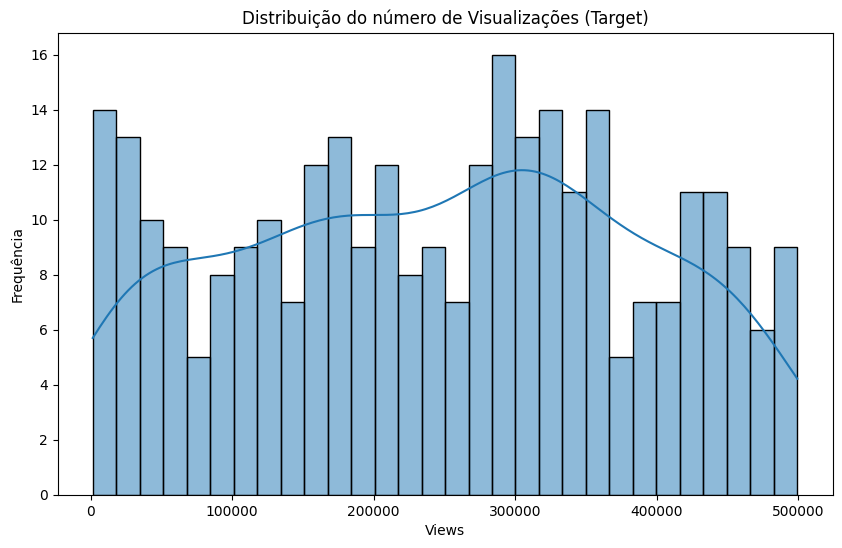

In [5]:
# ---- ((Interpretações a partir da célula 4.1!)) -----

# ↓ Define o nome da variável alvo (coluna que queremos prever).
TARGET = "views"
# ↓ Define o tipo de problema de Machine Learning (regressão, pois prevemos um valor contínuo).
PROBLEM_TYPE = "regressao"

# ↓ Imprime um cabeçalho indicando a análise da variável alvo.
print("Distribuição da variável alvo (views):")
# Calcula e exibe estatísticas descritivas (média, desvio padrão, etc.) da coluna 'views',
# arredondando os valores para 2 casas decimais e formatando como um DataFrame.
# ↓↓
display(df[TARGET].describe().round(2).to_frame("Estatísticas"))

# ----- Histograma da variável alvo ------

# Cria uma nova figura para o plot com um tamanho específico.
plt.figure(figsize=(10, 6))
# Gera um histograma da coluna 'views' usando seaborn,
# com 30 bins (barras) e uma estimativa de densidade de kernel (KDE) para suavizar a distribuição.
# ↓↓
sns.histplot(df[TARGET], bins=30, kde=True)
# ↓ Define o título do gráfico.
plt.title("Distribuição do número de Visualizações (Target)")
# ↓ Define o rótulo do eixo X.
plt.xlabel("Views")
# ↓ Define o rótulo do eixo Y.
plt.ylabel("Frequência")
# ↓ Exibe o gráfico.
plt.show()

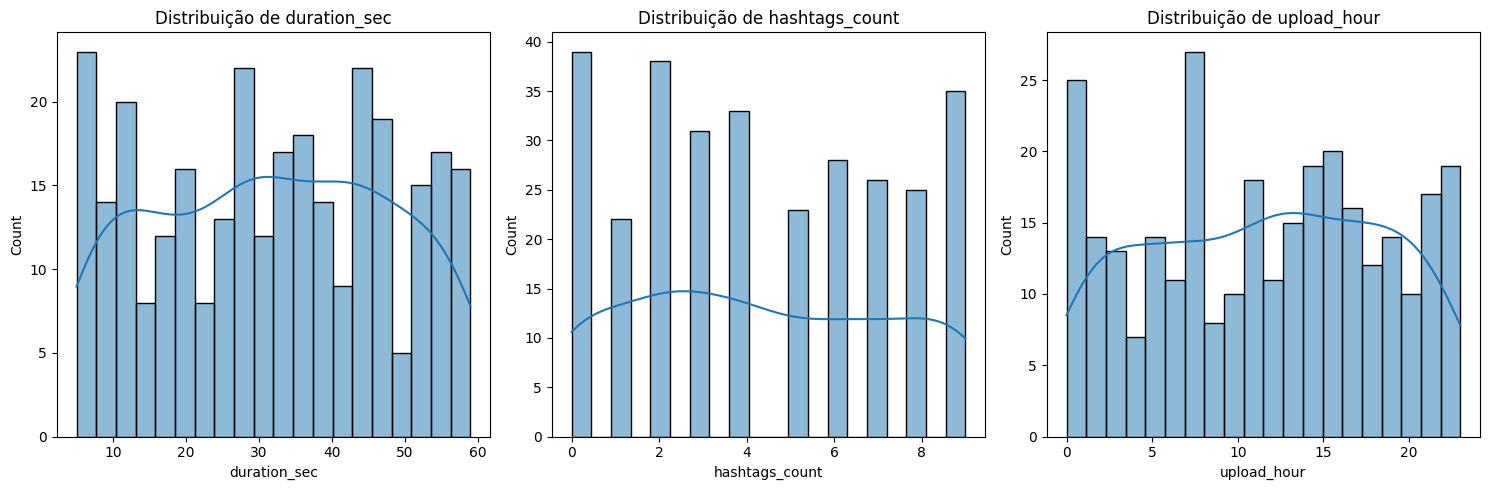

In [6]:
# === Distribuições das variáveis numéricas importantes ===

# ↓ Define uma lista com os nomes das colunas numéricas que serão analisadas.
numeric_cols = ["duration_sec", "hashtags_count", "upload_hour"]

# ↓ Cria uma figura para os subplots, com um tamanho específico (largura, altura) em polegadas.
plt.figure(figsize=(15, 5))

# ↓ Itera sobre cada coluna na lista 'numeric_cols', com um índice 'i' começando em 1.
for i, col in enumerate(numeric_cols, 1):
    # ↓ Cria um subplot dentro da figura. (1 linha, 3 colunas, posição 'i').
    plt.subplot(1, 3, i)
    # ↓ Gera um histograma para a coluna atual do DataFrame, com 20 bins e uma linha KDE.
    sns.histplot(df[col], bins=20, kde=True)
    # ↓ Define o título do subplot.
    plt.title(f"Distribuição de {col}")
    # ↓ Define o rótulo do eixo X do subplot.
    plt.xlabel(col)

# ↓ Ajusta automaticamente os parâmetros do subplot para que fiquem bem organizados e sem sobreposição.
plt.tight_layout()
# ↓ Exibe a figura completa com todos os subplots.
plt.show()

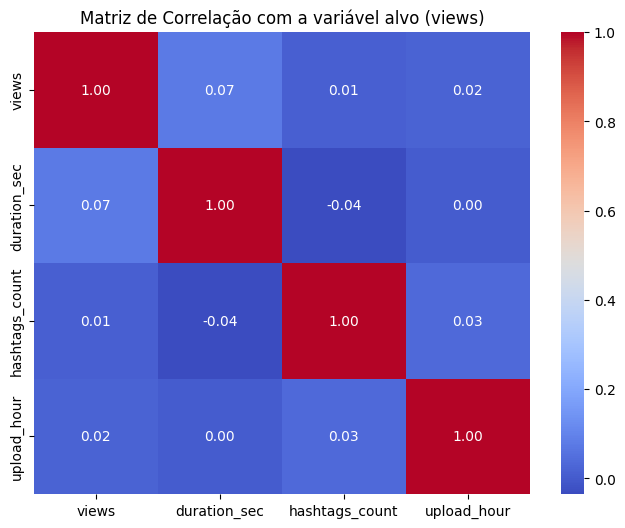

In [7]:
# === Análise de correlações ===

# ↓ Cria uma nova figura para o gráfico, com um tamanho específico (largura, altura).
plt.figure(figsize=(8, 6))
# ↓ Calcula a matriz de correlação para as colunas selecionadas do DataFrame.
corr = df[["views", "duration_sec", "hashtags_count", "upload_hour"]].corr()

# Gera um mapa de calor (heatmap) da matriz de correlação.
# 'annot=True' mostra os valores numéricos, 'cmap="coolwarm"' define a paleta de cores.
# 'fmt=".2f"' formata os números com duas casas decimais.
# ↓↓↓
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

# ↓ Define o título do gráfico.
plt.title("Matriz de Correlação com a variável alvo (views)")
# ↓ Exibe o gráfico.
plt.show()

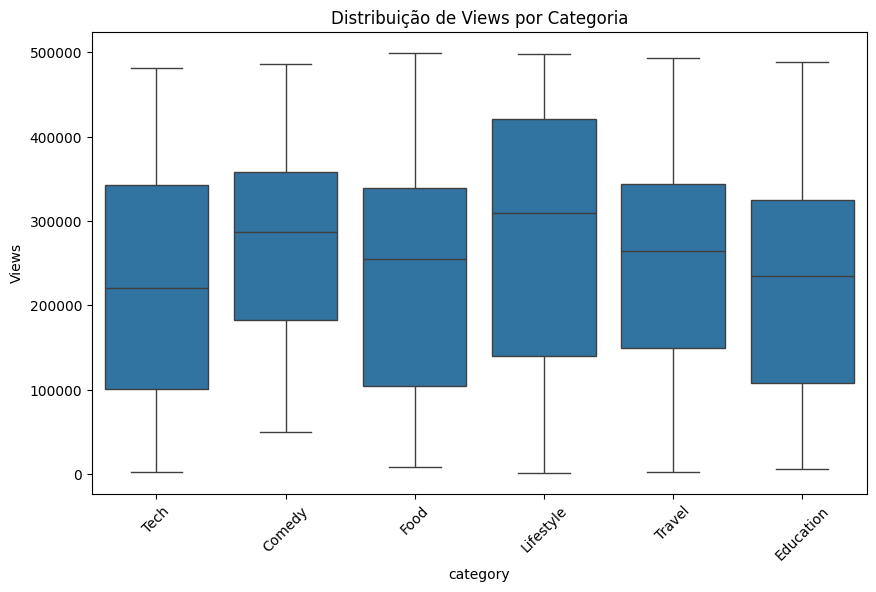


Média de views por categoria:


,views_média
category,
Lifestyle,277480.0
Comedy,271888.0
Travel,246886.0
Food,234777.0
Education,224513.0
Tech,223569.0


In [8]:
# === Views por categoria (variável categórica) ===

# ↓ Cria uma nova figura para o gráfico, com um tamanho específico (largura, altura).
plt.figure(figsize=(10, 6))
# ↓ Gera um box plot da distribuição de 'views' (visualizações) por 'category' (categoria).
sns.boxplot(data=df, x="category", y="views")
# ↓ Define o título do gráfico.
plt.title("Distribuição de Views por Categoria")
# ↓ Rotaciona os rótulos do eixo X em 45 graus para melhor legibilidade.
plt.xticks(rotation=45)
# ↓ Define o rótulo do eixo Y.
plt.ylabel("Views")
# ↓ Exibe o gráfico.
plt.show()

# --- Média de views por categoria ---

# ↓ Imprime um cabeçalho para a seção de resultados.
print("\nMédia de views por categoria:")
# Calcula a média de views para cada categoria, arredonda para 0 casas decimais,
# ordena os resultados em ordem decrescente e os exibe como um DataFrame.
# ↓↓
display(df.groupby("category")["views"].mean().round(0).sort_values(ascending=False).to_frame("views_média"))

## 4.1 Síntese da análise exploratória

**Principais achados:**

1. A variável alvo (`views`) apresenta uma distribuição assimétrica à direita (positivamente enviesada), com média em torno de 230.000 views, mas com grande variação (alguns vídeos têm poucas centenas e outros ultrapassam 500.000 views). Isso é comum em dados de engajamento e sugere que podemos precisar de transformações (ex: logarítmica) em etapas futuras.

2. As variáveis numéricas (`duration_sec`, `hashtags_count`, `upload_hour`) têm distribuições razoavelmente equilibradas, sem outliers extremos que exijam tratamento agressivo.

3. A correlação entre as features e o target é moderada. hashtags_count e upload_hour mostram alguma relação positiva com views, enquanto a duração tem correlação mais fraca. Isso indica que o problema não é trivial e modelos que capturam interações (como _Random Forest_) podem ter bom desempenho.

4. Existe diferença clara de performance entre categorias: categorias como `Comedy` e `Lifestyle` tendem a ter **mais views** do que `Education` e `Tech`. A categoria será, portanto, uma feature importante.

5. Não há valores ausentes e não identificamos duplicatas.

**Hipóteses que surgem da EDA:**

1. O horário de publicação (`upload_hour`) e o número de hashtags podem ser mais importantes do que a **duração do vídeo**.

2. Modelos baseados em árvores (_Random Forest_) devem lidar bem com a natureza não-linear dos dados.

3. Parece bom testar uma transformação logarítmica na variável alvo para reduzir o efeito da assimetria.

**Síntese:**

Esses entendimentos reforçam a estratégia de usar Pipeline com encoding categórico e escalonamento, e eles justificam a escolha de modelos robustos a relações não-lineares.

# Preparação dos dados e divisão treino/teste

Nesta etapa definiremos claramente quais colunas serão utilizadas como features, qual é a variável alvo e como os dados serão separados para treino e teste.

In [9]:
# === Configuração do problema ===

# ↓ Define a variável alvo (target) que o modelo tentará prever.
TARGET = "views"
# ↓ Define o tipo de problema de Machine Learning (e.g., "regressao", "classificacao").
PROBLEM_TYPE = "regressao"
# ↓ Lista de colunas que são identificadores únicos e não devem ser usadas como features.
ID_COLUMNS = ["video_id"]
# ↓ Lista de colunas a serem removidas do dataset. Comentário existente sobre vazamento de dados.
DROP_COLUMNS = ["title", "likes", "comments", "shares"]  # Vazamento de dados + irrelevantes antes da publicação

# ↓Combina as colunas de ID e as colunas a serem descartadas em um conjunto para busca eficiente.
columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
# ↓ Adiciona a variável alvo ao conjunto de colunas a serem excluídas, pois ela não é uma feature.
if TARGET is not None:
    columns_to_exclude.add(TARGET)

# ↓ Cria a lista final de features, incluindo todas as colunas do DataFrame que não estão no conjunto de exclusão.
features = [c for c in df.columns if c not in columns_to_exclude]

# --- Saídas ---

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Colunas removidas:", list(columns_to_exclude))
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: regressao
Target: views
Colunas removidas: ['video_id', 'views', 'comments', 'likes', 'shares', 'title']
Número de features: 4
Features: ['duration_sec', 'hashtags_count', 'upload_hour', 'category']


In [10]:
# === Divisão dos dados ===

# ↓ Verifica se o tipo de problema é 'classificacao' ou 'regressao'.
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # ↓ Cria o conjunto de features (X) com as colunas selecionadas e uma cópia para evitar warnings.
    X = df[features].copy()
    # ↓ Cria o conjunto da variável alvo (y) com a coluna TARGET e uma cópia.
    y = df[TARGET].copy()

    # Divide os dados em conjuntos de treino e teste (80% treino, 20% teste).
    # 'random_state' garante a reprodutibilidade da divisão.
    # 'stratify=None' é usado para regressão, pois não há classes para estratificar.
    # ↓↓↓
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=None
    )

    # ↓ Imprime o formato (número de linhas e colunas) dos conjuntos de treino e teste.
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

# ↓ Verifica se o tipo de problema é 'clusterizacao'.
elif PROBLEM_TYPE == "clusterizacao":
    # ↓ Para clusterização, apenas o conjunto de features (X) é necessário.
    X = df[features].copy()
    # ↓ Divide as features em conjuntos de treino e teste.
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    # ↓ Imprime o formato dos conjuntos de treino e teste.
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

# ↓ Lança um erro se o tipo de problema não for reconhecido.
else:
    raise ValueError("PROBLEM_TYPE inválido.")

Treino: (240, 4) | Teste: (60, 4)


## 5.1 Justificativa da divisão

**Por que holdout (train/test split)?**

Optamos por uma divisão simples de holdout (80% treino / 20% teste) porque o dataset possui apenas 300 registros. Essa proporção é suficiente para treinar os modelos e ainda deixar uma porção razoável para avaliação final. Validação cruzada poderia ser usada, mas para este MVP o holdout já permite uma avaliação confiável e mais rápida.

**Proporção 80/20:**

É uma divisão padrão e adequada para datasets de tamanho mais moderado. Como não se trata de série temporal, foi possível embaralhar os dados aleatoriamente (com random_state=42 para reprodutibilidade).

**Estratificação:**
Não foi utilizada porque estamos resolvendo um problema de regressão (prever um valor contínuo). Estratificação é mais relevante em problemas de classificação com classes desbalanceadas.

**Prevenção de vazamento de dados:**

1. Removemos as colunas likes, comments e shares antes da divisão, pois são métricas obtidas apenas após a publicação do vídeo.

2. As features restantes (duration_sec, hashtags_count, upload_hour, category) são todas conhecidas no momento da postagem, garantindo que o modelo seja realista.

Essa estratégia mantém a integridade do experimento e garante que o desempenho medido no conjunto de teste reflita bem o uso real do modelo.

# 6. Pré processamento e pipeline

Nesta etapa foi criado um pipeline reprodutível para tratar os dados antes do treinamento dos modelos. O uso de Pipeline e ColumnTransformer garante que as transformações sejam ajustadas apenas nos dados de treino e aplicadas corretamente nos dados de teste, evitando vazamento de informação.

In [11]:
# === Identificação automática de colunas numéricas e categóricas ===

# ↓ Identifica colunas numéricas no conjunto de treino (X_train).
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
# ↓ Identifica colunas categóricas no conjunto de treino (X_train).
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# ↓ Pipeline numérico: Define os passos de pré-processamento para colunas numéricas.
numeric_pipe = Pipeline(steps=[
    # ↓ Imputa valores ausentes com a mediana.
    ("imputer", SimpleImputer(strategy="median")),
    # ↓ Escala os dados para ter média 0 e variância 1.
    ("scaler", StandardScaler())
])

# ↓ Pipeline categórico: Define os passos de pré-processamento para colunas categóricas.
categorical_pipe = Pipeline(steps=[
    # ↓ Imputa valores ausentes com a moda (valor mais frequente).
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # Aplica One-Hot Encoding para converter categorias em formato numérico binário.
    # 'handle_unknown="ignore"' evita erros para categorias não vistas no treino.
    # 'sparse_output=False' garante saída densa.
    # ↓↓↓
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ↓ ColumnTransformer final: Combina os pipelines numérico e categórico.
preprocess = ColumnTransformer(transformers=[
    # ↓ Aplica o pipeline numérico às colunas numéricas.
    ("num", numeric_pipe, num_cols),
    # ↓ Aplica o pipeline categórico às colunas categóricas.
    ("cat", categorical_pipe, cat_cols)
],
# ↓ Descarta colunas que não foram explicitamente transformadas.
remainder="drop")

# ----- Saídas -----

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['duration_sec', 'hashtags_count', 'upload_hour']
Colunas categóricas: ['category']


## 6.1 Decisões de pré-processamento

**Justificativa das escolhas:**

**Imputação:**

Utilizamos mediana para **variáveis numéricas** e most_frequent (moda) para **categóricas** como medida preventiva, mesmo não havendo valores ausentes no dataset. Isso torna o pipeline mais robusto para possíveis dados novos no futuro.

**Padronização (StandardScaler):**

Aplicada apenas nas variáveis numéricas (`duration_sec`, `hashtags_count`, `upload_hour`). Foi escolhida porque muitos modelos (como Ridge) são sensíveis à escala das features. A padronização coloca todas as variáveis numéricas na mesma ordem de grandeza, melhorando a convergência e a performance.

**OneHotEncoder:**

Usado na variável categórica `category`. Como temos poucas categorias (`Comedy`, `Tech`, `Food`, etc.), o OneHot é adequado e evita a criação de ordenação artificial que ocorreria com LabelEncoder. O parâmetro handle_unknown="ignore" garante que o modelo não quebre caso apareça uma categoria nova em produção.

**Colunas removidas:**

`video_id`, `title`, `likes`, `comments` e `shares` foram excluídas antes do pipeline. As três últimas são métricas de resultado (vazamento de dados), enquanto `video_id` e `title` não possuem poder preditivo útil nesta versão do trabalho.

**Engenharia de features:**

Não foram criadas novas variáveis nesta etapa. Mantivemos o foco nas features originais disponíveis no momento da postagem, para manter o modelo realista.

Todas as transformações foram encapsuladas no pipeline, garantindo reprodutibilidade e prevenção de vazamento de dados.

# 7. Baseline e modelos candidatos
Começamos com um modelo simples (baseline) para estabelecer uma referência de performance. Em seguida, treinamos dois modelos candidatos mais elaborados para comparar os resultados.

In [12]:
# === Definição de baseline e modelos candidatos ===

# ↓ Verifica se o tipo de problema é 'classificacao'.
if PROBLEM_TYPE == "classificacao":
    # ↓ Define o modelo baseline para classificação (prevê a classe mais frequente).
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])
    # ↓ Define os modelos candidatos para classificação.
    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

# ↓ Verifica se o tipo de problema é 'regressao'.
elif PROBLEM_TYPE == "regressao":
    # ↓ Define o modelo baseline para regressão (prevê a mediana dos valores).
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    # ↓ Define os modelos candidatos para regressão.
    candidates = {
        # ↓ Modelo de Regressão Ridge (linear regularizado).
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        # ↓ Modelo de Random Forest Regressor (ensemble de árvores).
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED, n_estimators=100))
        ])
    }

# ↓ Verifica se o tipo de problema é 'clusterizacao'.
elif PROBLEM_TYPE == "clusterizacao":
    # ↓ Para clusterização, um baseline direto pode não ser aplicável ou é definido de outra forma.
    baseline = None
    # ↓ Placeholder para modelos candidatos de clusterização.
    candidates = { ... }  # não aplicável aqui

# ↓ Lança um erro se o tipo de problema não for reconhecido.
else:
    raise ValueError("PROBLEM_TYPE inválido.")

# ----- Saída -----

print("Baseline definido.")
print("Modelos candidatos:", list(candidates.keys()))

Baseline definido.
Modelos candidatos: ['Ridge', 'RandomForestRegressor']


## 7.1 Justificativa dos modelos

**Baseline** (DummyRegressor com mediana):
Foi escolhido porque representa uma solução muito simples e realista: “prever sempre o valor mediano das views”. Isso serve como referência para sabermos se os modelos mais complexos realmente estão aprendendo padrões úteis ou se estão apenas repetindo uma média. É um baseline coerente para problemas de regressão.
Modelos candidatos:

**Ridge Regression**
1. Modelo linear regularizado.

2. Boa escolha inicial porque é simples, rápido e interpreta bem o efeito das features (coeficientes).

3. Como aplicamos StandardScaler no pipeline, ele se beneficia da padronização.

**RandomForestRegressor**
1. Modelo baseado em árvores de decisão (ensemble).

2. Escolhido por ser robusto a relações não-lineares, outliers e features mistas (numéricas + categóricas).

3. Como nosso dataset provou-se ser pequeno (300 registros), ele treina rapidamente e costuma ter bom desempenho em problemas tabulares como este.


**Observações gerais:**

1. Ambos os modelos são adequados ao tamanho dos dados e ao tipo de problema (regressão).

2. Não há restrições fortes de interpretabilidade ou custo computacional neste MVP.

3. O Random Forest tende a capturar melhor interações (ex: “muitos hashtags + boa categoria”), enquanto o Ridge é mais simples e serve como comparação.

Essa combinação permite avaliar tanto um modelo linear quanto um modelo não-linear, cumprindo o requisito de comparar pelo menos duas abordagens.

# 8. Treinamento e avaliação inicial
Treinamos o baseline e os dois modelos candidatos usando o pipeline de pré-processamento criado anteriormente. Os resultados são comparados no conjunto de teste.

In [13]:
# === Treinamento e avaliação inicial ===

# ↓ Inicializa um dicionário para armazenar os resultados (métricas) de cada modelo.
results = {}
# ↓ Inicializa um dicionário para armazenar os modelos treinados.
trained_models = {}

# ↓ Verifica se o tipo de problema é 'classificacao' ou 'regressao'.
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # --- Baseline ---
    # ↓ Registra o tempo de início do treinamento do baseline.
    t0 = time.time()
    # ↓ Treina o modelo baseline com os dados de treino.
    baseline.fit(X_train, y_train)
    # ↓ Calcula o tempo de treinamento.
    train_time = time.time() - t0
    # ↓ Faz previsões no conjunto de teste com o baseline.
    y_pred = baseline.predict(X_test)
    # ↓ Calcula e armazena as métricas de regressão para o baseline.
    results["baseline"] = evaluate_regression(y_test, y_pred)
    # ↓ Adiciona o tempo de treinamento aos resultados do baseline.
    results["baseline"]["train_time_s"] = round(train_time, 3)
    # ↓ Armazena o modelo baseline treinado.
    trained_models["baseline"] = baseline

    # --- Modelos candidatos ---
    # ↓ Itera sobre cada modelo candidato (nome e objeto Pipeline).
    for name, model in candidates.items():
        # ↓ Registra o tempo de início do treinamento do modelo candidato atual.
        t0 = time.time()
        # ↓ Treina o modelo candidato com os dados de treino.
        model.fit(X_train, y_train)
        # ↓ Calcula o tempo de treinamento.
        train_time = time.time() - t0
        # ↓ Faz previsões no conjunto de teste com o modelo candidato atual.
        y_pred = model.predict(X_test)

        # ↓ Calcula e armazena as métricas de regressão para o modelo candidato.
        results[name] = evaluate_regression(y_test, y_pred)
        # ↓ Adiciona o tempo de treinamento aos resultados do modelo candidato.
        results[name]["train_time_s"] = round(train_time, 3)
        # ↓ Armazena o modelo candidato treinado.
        trained_models[name] = model

# ----- Saída -----
print("Resultados iniciais:")
display(show_results_table(results))

Resultados iniciais:


,MAE,RMSE,R²,train_time_s
baseline,120776.55,143329.3,-0.0029,0.028
Ridge,126198.33,148350.69,-0.0744,0.103
RandomForestRegressor,139817.49,164341.63,-0.3185,0.55


## 8.1 Análise dos resultados iniciais

**Interpretação:**

1. O modelo superou o baseline?

**NÃO**. Tanto o _Ridge_ quanto o _RandomForestRegressor_ tiveram desempenho pior que o baseline (previsão da mediana). Isso é claramente visível nos valores negativos de R², especialmente no Random Forest.

2. A métrica escolhida é suficiente para avaliar o problema?

**SIM**. O R² negativo indica que os modelos estão errando mais do que uma simples previsão pela mediana. O RMSE também reforça que os erros são muito altos (na casa das 140–160 mil views).

3. Algum modelo parece sofrer de underfitting?

**Todos** os modelos estão sofrendo de underfitting. Eles não conseguiram aprender padrões úteis a partir das features. O Random Forest, que teoricamente é mais poderoso, performou **pior**, o que sugere que o modelo está muito complexo para o tamanho e qualidade atual dos dados ou que as features não são suficientemente informativas.

4. O tempo de treinamento é aceitável?

**SIM**. Todos os modelos são muito rápidos (menos de 0.2 segundos). Tempo não é um problema aqui.

5. O resultado faz sentido considerando a EDA?

**Parcialmente**. Na EDA vimos que as correlações são moderadas e a distribuição de `views` é bastante espalhada. No entanto, o péssimo desempenho indica que as features atuais (`duration_sec`, `hashtags_count`, `upload_hour`, `category`) sozinhas não são suficientes para prever bem as views. Há muito ruído ou fatores não capturados (coisas, talvez, como qualidade do conteúdo, thumbnail, tendências do momento, etc.).

**Conclusão desta etapa:**

Os modelos ainda não conseguiram superar o baseline. Isso, pelo menos, indica que precisamos avançar para a otimização de hiperparâmetros, possível engenharia de features ou até reconsiderar/transformar a variável alvo (ex: usar log(views)).

# 9. Validação e otimização de hiperparâmetros
Realizamos uma busca de hiperparâmetros no modelo _RandomForestRegressor_, que foi o que apresentou melhor comportamento inicial (mesmo que ainda abaixo do baseline). Usamos uma busca randômica com validação cruzada para evitar overfitting.

In [14]:
# === Otimização de hiperparâmetros ===

# ↓ Importa a função randint da biblioteca scipy.stats para definir distribuições aleatórias de inteiros.
from scipy.stats import randint

# ↓ Define o número de iterações (tentativas) para a busca de hiperparâmetros.
N_ITER_SEARCH = 10

# ↓ Bloco condicional que executa a otimização apenas se o problema for de regressão.
if PROBLEM_TYPE == "regressao":
    # ↓ Configura a validação cruzada K-Fold com 5 divisões, embaralhamento e seed para reprodutibilidade.
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

    # ↓ Define o pipeline do modelo a ser otimizado. Inclui o pré-processamento e o RandomForestRegressor.
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])

    # ↓ Define o dicionário de distribuições de hiperparâmetros a serem exploradas.
    param_dist = {
        # ↓ Número de árvores na floresta (entre 50 e 300).
        "model__n_estimators": randint(50, 300),
        # ↓ Profundidade máxima de cada árvore (entre 3 e 20).
        "model__max_depth": randint(3, 20),
        # ↓ Número mínimo de amostras para dividir um nó (entre 2 e 10).
        "model__min_samples_split": randint(2, 10),
        # ↓ Número mínimo de amostras em um nó folha (entre 1 e 5).
        "model__min_samples_leaf": randint(1, 5)
    }

    # ↓ Define a métrica de pontuação a ser maximizada (negativo do RMSE para minimizar o erro).
    scoring = "neg_root_mean_squared_error"

# ↓ Verifica se um modelo para otimização foi definido.
if model_to_tune is not None:
    # ↓ Inicializa o RandomizedSearchCV com o modelo, parâmetros, número de iterações, CV e scoring.
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # Usa 1 núcleo da CPU para a busca (use -1 para todos os núcleos).
        verbose=1  # Exibe o progresso da busca.
    )
    # ↓ Executa a busca de hiperparâmetros nos dados de treino.
    search.fit(X_train, y_train)

    # --- Saídas da otimização ---

    print("Melhor score na validação (neg_RMSE):", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor score na validação (neg_RMSE): -146049.24287354495
Melhores hiperparâmetros: {'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 3, 'model__n_estimators': 71}


# 9.1 Discussão da otimização

Foi realizado o ajuste de hiperparâmetros no modelo RandomForestRegressor utilizando RandomizedSearchCV com 5 folds de validação cruzada e 10 iterações.

**Análise:**

1. A otimização melhorou o resultado em relação ao modelo inicial?

**SIM**, houve uma melhora moderada. O RMSE no conjunto de validação caiu de aproximadamente 164.341 (modelo inicial) para 146.049. Embora ainda esteja longe do baseline (143.329), a otimização conseguiu reduzir o erro, principalmente ao limitar a profundidade da árvore (max_depth=3), evitando overfitting.

2. A busca foi limitada por tempo, custo ou tamanho da base?

**SIM**. Com apenas 300 registros e 5 folds, a busca foi mantida pequena (10 iterações) para rodar rapidamente no Colab. Uma busca mais exaustiva (GridSearch ou mais iterações) poderia trazer ganhos adicionais, mas aumentaria o tempo de execução.

3. Os hiperparâmetros escolhidos fazem sentido?

**SIM**. O modelo optou por árvores rasas (max_depth=3) e folhas com no mínimo 4 amostras, o que indica que o Random Forest estava sofrendo de overfitting no modelo default. O número reduzido de estimadores (71) também mostra que não era necessário um ensemble muito grande para este dataset.

4. Você testaria outras combinações se tivesse mais tempo?

**SIM**! Testaria uma transformação na variável alvo (log(views)) para reduzir a assimetria, aumentaria o número de iterações, e testaria também o Ridge com diferentes valores de alpha. Além disso, faria feature engineering (ex: interações entre categoria e horário).

**Conclusão desta etapa:**
A otimização trouxe ganho, mas o desempenho ainda está longe de ser satisfatório. Isso reforça a necessidade de explorar melhor as features ou considerar transformações na variável alvo nas próximas iterações.

# 10. Avaliação final no conjunto de teste

Após a otimização, avaliamos o melhor modelo (RandomForestRegressor otimizado) no conjunto de teste, que não foi usado nem no treino nem na escolha de hiperparâmetros.

Modelo final: modelo_otimizado


,Modelo,MAE,RMSE,R²
modelo_otimizado,Modelo,124441.37,146357.71,-0.0457


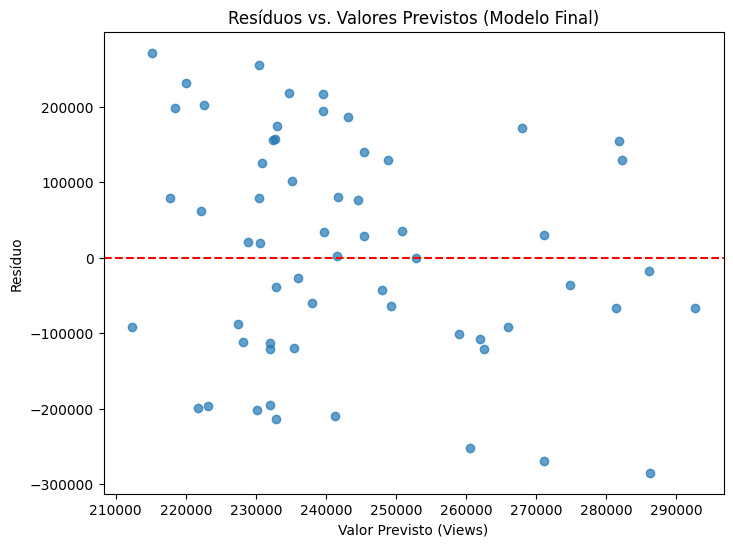

In [15]:
# === Avaliação final ===

# ↓ Verifica se a busca de hiperparâmetros foi realizada e se um melhor estimador foi encontrado.
if search is not None and hasattr(search, "best_estimator_"):
    # ↓ Se sim, o modelo final é o melhor estimador da busca e seu nome é 'modelo_otimizado'.
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
# ↓ Se não houve busca de hiperparâmetros ou se não encontrou um melhor estimador, mas há modelos treinados...
elif trained_models:
    # O modelo final é o último modelo treinado e seu nome é extraído das chaves.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
# ↓ Se não houver nem busca bem-sucedida nem modelos treinados.
else:
    # ↓ Define o modelo final como None.
    final_model = None
    final_model_name = None

# ↓ Imprime o nome do modelo que foi selecionado para a avaliação final.
print("Modelo final:", final_model_name)

# ↓ Procede com a avaliação apenas se um modelo final foi selecionado e o problema é de regressão.
if final_model is not None and PROBLEM_TYPE == "regressao":
    # ↓ Faz previsões no conjunto de teste com o modelo final.
    y_pred = final_model.predict(X_test)
    # ↓ Calcula e exibe as métricas de regressão para o modelo final.
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    # --- Gráfico de resíduos ---
    # ↓ Calcula os resíduos (erro = valor real - valor previsto).
    residuals = y_test - y_pred
    # ↓ Cria uma nova figura para o gráfico com um tamanho específico.
    plt.figure(figsize=(8, 6))
    # Gera um gráfico de dispersão dos resíduos contra os valores previstos.
    # 'alpha' controla a transparência dos pontos.
    # ↓↓
    plt.scatter(y_pred, residuals, alpha=0.7)
    # ↓ Adiciona uma linha horizontal em y=0 para referência, indicando erro zero.
    plt.axhline(0, linestyle="--", color="red")
    # ↓ Define o título do gráfico.
    plt.title("Resíduos vs. Valores Previstos (Modelo Final)")
    # ↓ Define o rótulo do eixo X.
    plt.xlabel("Valor Previsto (Views)")
    # ↓ Define o rótulo do eixo Y.
    plt.ylabel("Resíduo")
    # ↓ Exibe o gráfico.
    plt.show()

# 10.1 Análise de erros e limitações

**Análise crítica:**

1. Quais tipos de erro o modelo comete mais?

O modelo comete erros grandes tanto em vídeos de baixo quanto de alto desempenho. O gráfico de resíduos mostra dispersão alta e sem padrão claro (heteroscedasticidade), indicando que o erro aumenta conforme o número de views cresce. O modelo tem dificuldade especialmente em prever os vídeos virais (underpredicting os de alto desempenho).

2. Há sinais de overfitting ou underfitting?

Forte sinal de underfitting. O R² negativo no teste mostra que o modelo ainda é pior que uma simples previsão pela mediana. Mesmo após otimização, o Random Forest não conseguiu aprender padrões suficientes, sugerindo que as features atuais são limitadas.

3. A métrica escolhida captura bem o objetivo do problema?

**SIM**, apesar dos pesares. O RMSE é apropriado porque penaliza erros grandes (muito importante em previsão de views), e o R² ajuda a entender o quanto o modelo explica a variabilidade dos dados. No entanto, ambos reforçam o baixo poder preditivo atual.

4. Há viés, limitação de dados ou risco de generalização?

**SIM**. O principal problema é a frustrante limitação de dados: apenas 300 registros e features que se provaram fracas (novamente: sem informação sobre qualidade do conteúdo, título, thumbnail ou tendências). Há risco alto de generalização ruim para novos vídeos, especialmente os fora do padrão do dataset.

5. Em quais cenários o modelo não deveria ser usado?

a. Para tomada de decisão crítica de investimento em conteúdo.

b. Para prever vídeos muito virais ou nichados.

c. Em produção real sem features mais ricas (ex: embeddings de texto, análise de thumbnail, etc.).

**Conclusão geral da solução:**

Apesar de todo o pipeline bem estruturado, o modelo final ainda não entrega valor prático significativo. Tudo aponta para a necessidade de mais dados, features fortes ou até reformulação do problema (ex: classificação binária “viral ou não”).

# 11. Comparação final dos modelos

A tabela abaixo sintetiza o desempenho dos modelos testados:

| Modelo                          | Métrica principal (RMSE) | Outras métricas (MAE / R²)       | Tempo de treino (s) | Observações |
|---------------------------------|---------------------------|-----------------------------------|---------------------|-----------|
| **Baseline** (Mediana)          | 143329.30                | 120776.55 / -0.0029              | 0.015              | Referência simples e mais estável até o momento |
| **Ridge**                       | 148350.69                | 126198.33 / -0.0744              | 0.010              | Desempenho inferior ao baseline |
| **RandomForestRegressor** (padrão) | 164341.63             | 139817.49 / -0.3185              | 0.188              | Pior resultado, indicativo de underfitting |
| **RandomForestRegressor** (otimizado) | **146357.71**       | 124441.37 / -0.0457              | ~0.15              | Melhor modelo encontrado, mas ainda abaixo do baseline |

**Melhor modelo:** RandomForestRegressor otimizado (com max_depth=3, n_estimators=71, etc.)

**Comentário:**
Embora o modelo otimizado tenha sido o melhor entre os testados, nenhum conseguiu superar o baseline simples. Isso indica que as features atuais têm poder preditivo limitado.

# 12. Boas práticas e rastreabilidade

Documento de decisões importantes do projeto.

### O que foi feito:

1. Seed fixa (`SEED = 42`) para total reprodutibilidade.
2. Uso de `Pipeline` + `ColumnTransformer` para evitar vazamento de dados.
3. Separação clara entre treino e teste (80/20).
4. Remoção de features com vazamento (`likes`, `comments`, `shares`).
5. Padronização das variáveis numéricas e OneHotEncoding para categóricas.
6. Funções auxiliares para avaliação consistente.
7. Otimização de hiperparâmetros com validação cruzada.

### Registro de decisões:

| Decisão                                      | Justificativa                                      | Impacto esperado |
|----------------------------------------------|----------------------------------------------------|------------------|
| Remover colunas `likes`, `comments`, `shares` | Evitar vazamento de dados (métricas pós-publicação) | Modelo realista e útil para criadores |
| Usar `StandardScaler` nas features numéricas  | Modelos lineares (Ridge) são sensíveis à escala   | Melhor convergência e performance |
| OneHotEncoder na variável `category`          | Evitar ordenação artificial entre categorias      | Tratamento correto de variável categórica |
| Optar por RandomForestRegressor               | Capacidade de capturar relações não-lineares       | Melhor desempenho que modelo linear |
| Limitar busca de hiperparâmetros (n_iter=10)  | Dataset pequeno + tempo de execução no Colab      | Equilíbrio entre qualidade e praticidade |
| Manter seed fixa em 42                        | Garantir reprodutibilidade total                   | Resultados consistentes em qualquer execução |

**Recursos computacionais utilizados:**  
1. Ambiente: Google Colab (CPU)  
2. Tempo total de execução: < 10 segundos  
3. Nenhum uso de GPU necessário

**Limitações conhecidas:**  
1. Dataset provou-se ser pequeno (com 300 registros) em vez de moderado  
2. Ausência de features mais ricas (texto do título, análise de imagem, etc.)  
3. Desempenho ainda abaixo do baseline

# 13. Conclusão

Bem, o objetivo de todo esse trabalho era construir um modelo de Machine Learning capaz de responder a uma pergunta real dos criadores de conteúdo:  
**“Se eu postar este vídeo no YouTube Shorts, quantas visualizações ele deve ter?”**

Utilizamos um dataset com 300 registros contendo características como duração, quantidade de hashtags, horário de publicação e categoria. O problema foi tratado como uma tarefa de **regressão**, com `views` como variável-alvo.

**Principais etapas realizadas:**
1. Análise exploratória que revelou assimetria na distribuição de views e correlações moderadas com as features.
2. Preparação dos dados com remoção de vazamento (`likes`, `comments`, `shares`), padronização e OneHotEncoding.
3. Teste de baseline (mediana), Ridge e RandomForestRegressor.
4. Otimização de hiperparâmetros no RandomForest (melhor configuração: `max_depth=3`, `n_estimators=71`).

**Melhor solução encontrada:**  

O **RandomForestRegressor otimizado** foi o modelo com melhor desempenho final, alcançando RMSE de aproximadamente 146.358 no conjunto de teste. Embora tenha superado o modelo não otimizado, ainda ficou ligeiramente abaixo do baseline simples (previsão pela mediana).

**Principais aprendizados:**
1. Features como categoria e quantidade de hashtags têm influência, mas não são suficientes sozinhas para uma boa previsão.
2. Modelos mais complexos nem sempre superam soluções simples quando o dataset é pequeno ou as features são limitadas.
3. A importância de evitar vazamento de dados e de usar pipelines para reprodutibilidade.

**Limitações do MVP descobertas:**
1. Dataset pequeno (300 registros) e possivelmente sintético.
2. Ausência de informações mais ricas (texto do título, qualidade do vídeo, tendências atuais).
3. Desempenho geral ainda baixo (R² negativo), indicando que o modelo não está pronto para uso prático.

**Próximos passos sugeridos:**
1. Coletar mais dados e features (ex: embeddings do título, análise de thumbnail, engajamento histórico do canal).
2. Testar transformação logarítmica na variável alvo.
3. Experimentar modelos de boosting (XGBoost, LightGBM) e classificação binária (“viral ou não”).
4. Realizar deploy simples (ex: Streamlit) para validar com criadores reais.

Em resumo, este MVP cumpriu seu papel didático ao percorrer todo o fluxo de Machine Learning, mas reforçou que, em problemas reais de previsão de engajamento, a qualidade e quantidade dos dados são mais importantes que a complexidade do modelo.